# Comparación de algoritmos de optimización
Este notebook implementa varios métodos de descenso de gradiente y compara su comportamiento sobre funciones de dos variables. Cada algoritmo guarda la trayectoria de iteraciones para poder graficar curvas de nivel y analizar convergencia y tiempo de ejecución.

Resultados para función: f1
Iteración:  182
f1 - Gradient Descent: x_opt=[0.0, -9.423963381411134], f_opt=0.314793, iterations=1000, time=0.0009s
Iteración:  0
f1 - Momentum GD: x_opt=[0.0, -9.466937451015017], f_opt=0.313396, iterations=1000, time=0.0010s
Iteración:  0
f1 - Nesterov GD: x_opt=[0.0, -9.459521196492982], f_opt=0.313636, iterations=1000, time=0.0011s
Iteración:  64
f1 - AdaGD: x_opt=[np.float64(0.0), np.float64(-6.3675574835991045)], f_opt=0.459798, iterations=1000, time=0.0022s
f1 - RMS GD: x_opt=[np.float64(0.0), np.float64(-96.24989026383233)], f_opt=0.031166, iterations=1000, time=0.0032s
f1 - Adam: x_opt=[np.float64(0.0), np.float64(-24.820261718646904)], f_opt=0.120673, iterations=1000, time=0.0029s
Resultados para función: f2
Iteración:  21
f2 - Gradient Descent: x_opt=[1.4965776766268452e-05, 6.78801083065127e-13], f_opt=0.000000, iterations=58, time=0.0000s
Iteración:  46
f2 - Momentum GD: x_opt=[1.5485512482541787e-05, 1.4500808912291724e-05], f_opt=0.000000, i

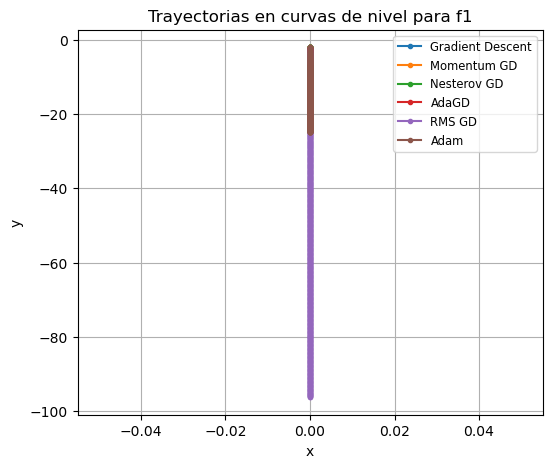

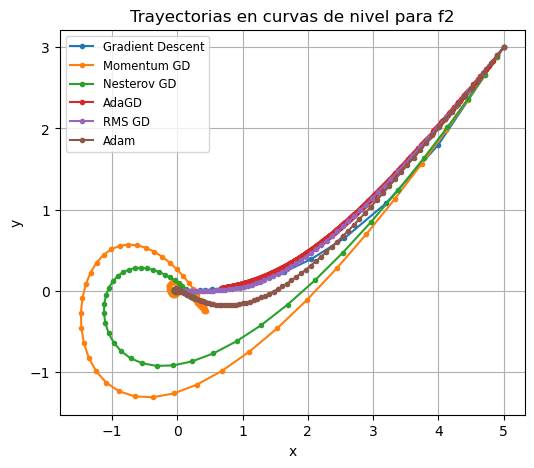

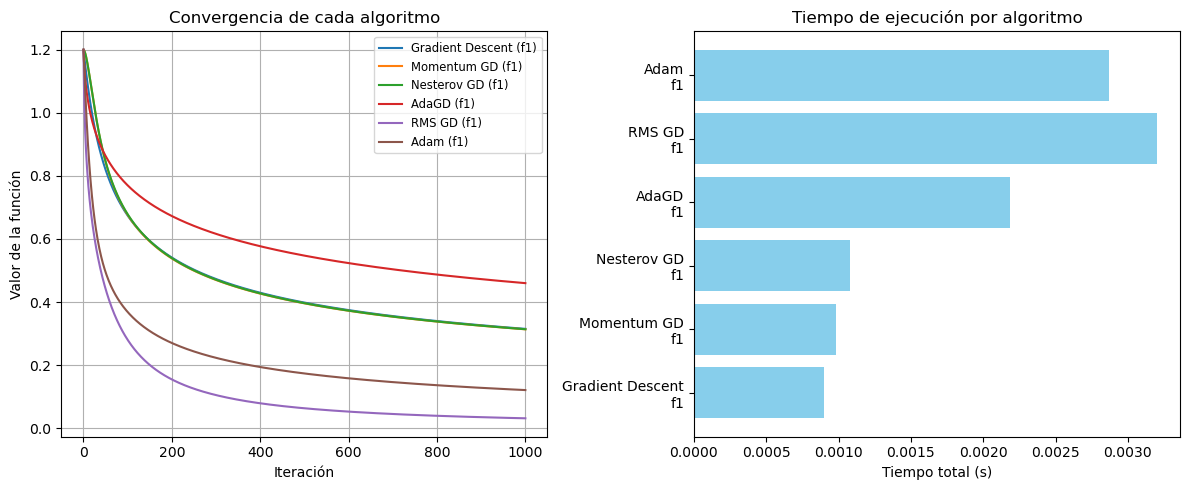

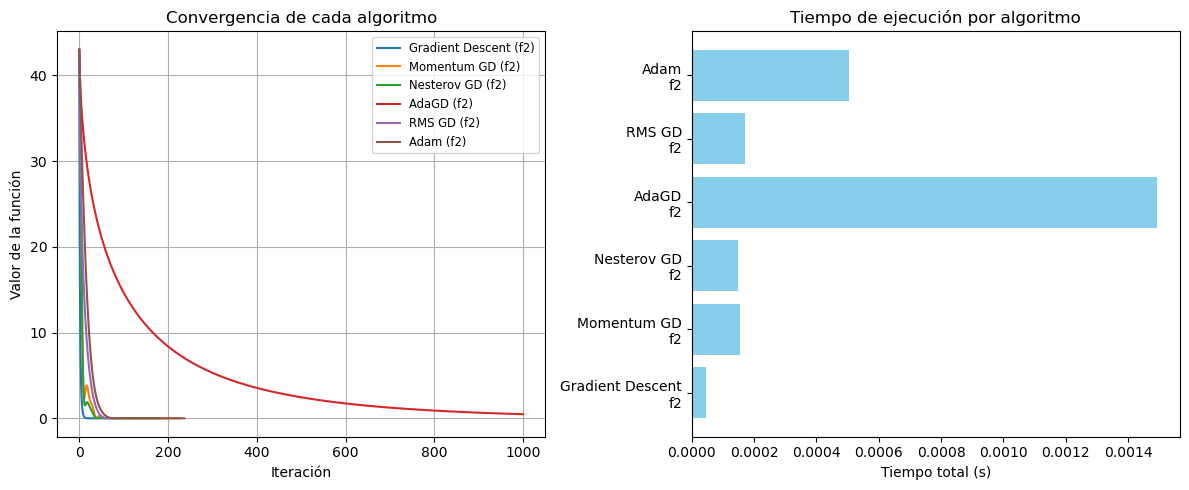

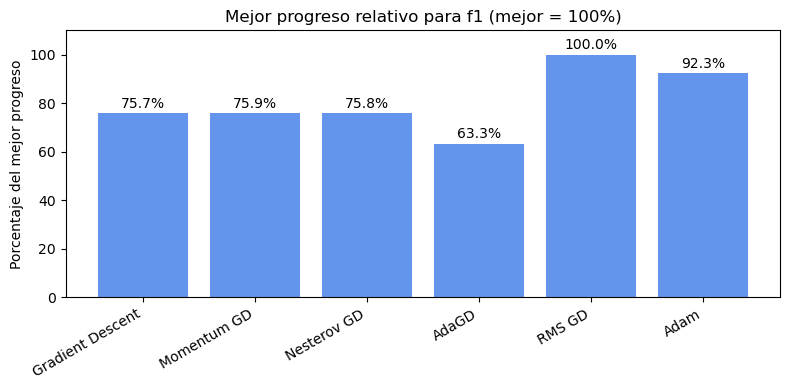

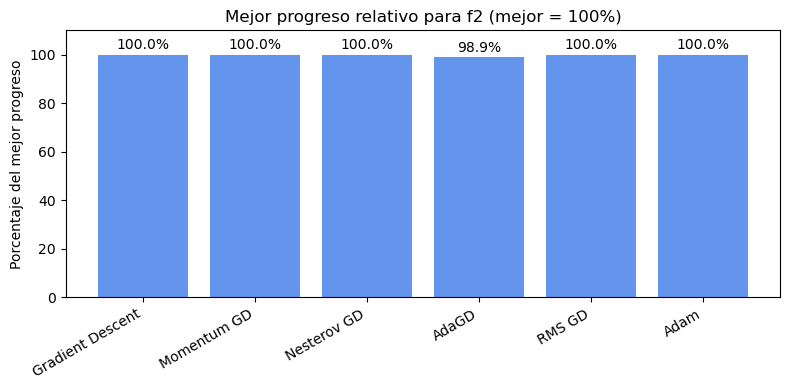

In [19]:
import time
import numpy as np
import matplotlib.pyplot as plt


def append_history(history, x, fx):
    if history is None:
        return
    history["x"].append(x.copy())
    history["f"].append(fx)


def gradientDescent(f, gradf, lambd, x0, tol, maxIter, history=None):
    size = len(x0)
    x_best = x0.copy()
    f_best = f(x_best)
    PRINT = True
    append_history(history, x_best, f_best)

    for i in range(maxIter):
        gradiente = gradf(x_best)
        new_x = [x_best[j] - lambd * gradiente[j] for j in range(size)]
        new_f = f(new_x)
        append_history(history, new_x, new_f)

        if ((new_x[0]-x_best[0])**2 + (new_x[1]-x_best[1])**2)**(1/2) < 0.01 and PRINT:
            print("Iteración: ", i)
            PRINT = False
        if abs(new_f - f_best) < tol:
            return x_best, f_best, i + 1

        x_best, f_best = new_x, new_f

    return x_best, f_best, maxIter


def momentumGD(f, gradf, lambd, b, v0, x0, tol, maxIter, history=None):
    size = len(x0)
    x_best = x0.copy()
    f_best = f(x_best)
    v = v0.copy()
    PRINT = True
    append_history(history, x_best, f_best)

    for i in range(maxIter):
        gradiente = gradf(x_best)
        new_x = x_best.copy()
        for j in range(size):
            v[j] = b * v[j] - lambd * (1 - b) * gradiente[j]
            new_x[j] = x_best[j] + v[j]

        new_f = f(new_x)
        append_history(history, new_x, new_f)
        if ((new_x[0]-x_best[0])**2 + (new_x[1]-x_best[1])**2)**(1/2) < 0.01 and PRINT:
            print("Iteración: ", i)
            PRINT = False
        if abs(new_f - f_best) < tol:
            return x_best, f_best, i + 1

        x_best, f_best = new_x, new_f

    return x_best, f_best, maxIter


def nesterovGD(f, gradf, lambd, b, v0, x0, tol, maxIter, history=None):
    size = len(x0)
    x_best = x0.copy()
    f_best = f(x_best)
    v = v0.copy()
    PRINT = True
    append_history(history, x_best, f_best)

    for i in range(maxIter):
        lookahead = [x_best[k] + b * v[k] for k in range(size)]
        gradiente = gradf(lookahead)
        new_x = x_best.copy()
        for j in range(size):
            v[j] = b * v[j] - lambd * (1 - b) * gradiente[j]
            new_x[j] = x_best[j] + v[j]

        new_f = f(new_x)
        append_history(history, new_x, new_f)

        if ((new_x[0]-x_best[0])**2 + (new_x[1]-x_best[1])**2)**(1/2) < 0.01 and PRINT:
            print("Iteración: ", i)
            PRINT = False
        if abs(new_f - f_best) < tol:
            return x_best, f_best, i + 1

        x_best, f_best = new_x, new_f

    return x_best, f_best, maxIter


def adaGD(f, gradf, lambd, b, v0, x0, tol, maxIter, history=None):
    size = len(x0)
    x_best = x0.copy()
    f_best = f(x_best)
    v = v0.copy()
    PRINT = True
    append_history(history, x_best, f_best)

    for i in range(maxIter):
        gradiente = gradf(x_best)
        v = [v[j] + gradiente[j] ** 2 + 1e-6 for j in range(size)]
        new_x = [x_best[j] - lambd / np.sqrt(v[j]) * gradiente[j] for j in range(size)]

        new_f = f(new_x)
        append_history(history, new_x, new_f)

        if ((new_x[0]-x_best[0])**2 + (new_x[1]-x_best[1])**2)**(1/2) < 0.01 and PRINT:
            print("Iteración: ", i)
            PRINT = False
        if abs(new_f - f_best) < tol:
            return x_best, f_best, i + 1

        x_best, f_best = new_x, new_f

    return x_best, f_best, maxIter


def rmsGD(f, gradf, lambd, b, v0, x0, tol, maxIter, history=None):
    size = len(x0)
    x_best = x0.copy()
    f_best = f(x_best)
    v = v0.copy()
    PRINT = True
    append_history(history, x_best, f_best)

    for i in range(maxIter):
        v = [b * v[j] + (1 - b) * gradiente ** 2 + 1e-10 for j, gradiente in enumerate(gradf(x_best))]
        new_x = [x_best[j] - lambd / np.sqrt(v[j]) * gradf(x_best)[j] for j in range(size)]

        new_f = f(new_x)
        append_history(history, new_x, new_f)
        
        if ((new_x[0]-x_best[0])**2 + (new_x[1]-x_best[1])**2)**(1/2) < 0.01 and PRINT:
            print("Iteración: ", i)
            PRINT = False
        if abs(new_f - f_best) < tol:
            return x_best, f_best, i + 1

        x_best, f_best = new_x, new_f

    return x_best, f_best, maxIter


def adam(f, gradf, lambd, b0, b1, v0, s0, x0, tol, maxIter, history=None):
    size = len(x0)
    x_best = x0.copy()
    f_best = f(x_best)
    v_curr = v0.copy()
    s_curr = s0.copy()
    PRINT = True
    append_history(history, x_best, f_best)

    for i in range(maxIter):
        gradiente = gradf(x_best)
        v_new = [b0 * v_curr[j] + (1 - b0) * gradiente[j] for j in range(size)]
        s_new = [b1 * s_curr[j] + (1 - b1) * gradiente[j] ** 2 for j in range(size)]
        new_x = [
            x_best[j] - lambd * (v_new[j] / (1 - b0 ** (i + 1))) / np.sqrt(s_new[j] / (1 - b1 ** (i + 1)) + 1e-12)
            for j in range(size)
        ]

        new_f = f(new_x)
        append_history(history, new_x, new_f)
        if ((new_x[0]-x_best[0])**2 + (new_x[1]-x_best[1])**2)**(1/2) < 0.01 and PRINT:
            print("Iteración: ", i)
            PRINT = False
        if abs(new_f - f_best) < tol:
            return x_best, f_best, i + 1

        x_best, f_best = new_x, new_f
        v_curr, s_curr = v_new, s_new

    return x_best, f_best, maxIter


def optimize(name, optimizer, f, gradf, args, x0, tol, maxIter):
    history = {"x": [], "f": []}
    start = time.perf_counter()
    x_opt, f_opt, iterations = optimizer(f, gradf, *args, x0.copy(), tol, maxIter, history=history)
    elapsed = time.perf_counter() - start
    return {
        "name": name,
        "x_opt": x_opt,
        "f_opt": f_opt,
        "iterations": iterations,
        "time": elapsed,
        "history": history,
    }


def plot_level_curves(f, x_history, title, levels=30):
    xs = np.array(x_history)
    margin = 1.0
    x_min, x_max = xs[:, 0].min() - margin, xs[:, 0].max() + margin
    y_min, y_max = xs[:, 1].min() - margin, xs[:, 1].max() + margin

    X, Y = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = np.array([f([x, y]) for x, y in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

    fig, ax = plt.subplots(figsize=(5, 4))
    contour = ax.contour(X, Y, Z, levels=levels, cmap="viridis")
    ax.plot(xs[:, 0], xs[:, 1], "-o", color="red", markersize=4, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(contour, ax=ax, label="f(x, y)")
    plt.show()


    plt.show()

def summary_plots(results):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for result in results:
        label = f"{result['name']} ({result['func']})"
        plt.plot(result["history"]["f"], label=label)
    plt.xlabel("Iteración")
    plt.ylabel("Valor de la función")
    plt.title("Convergencia de cada algoritmo")
    plt.legend(fontsize="small", loc="best")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    labels = [f"{r['name']}\n{r['func']}" for r in results]
    times = [r["time"] for r in results]
    plt.barh(labels, times, color="skyblue")
    plt.xlabel("Tiempo total (s)")
    plt.title("Tiempo de ejecución por algoritmo")
    plt.tight_layout()
    plt.show()

    plt.show()


def f1(x):
    return -3 * x[1] / (x[0] ** 2 + x[1] ** 2 + 1)


def gradf1(x):
    denom = (x[0] ** 2 + x[1] ** 2 + 1) ** 2
    return [6 * x[0] * x[1] / denom, -3 * (x[0] ** 2 - x[1] ** 2 + 1) / denom]


def f2(x):
    return x[0] ** 2 + 2 * x[1] ** 2


def gradf2(x):
    return [2 * x[0], 4 * x[1]]

algorithms = [
    ("Gradient Descent", gradientDescent, (0.1,)),
    ("Momentum GD", momentumGD, (0.1, 0.9, [0.0, 0.0])),
    ("Nesterov GD", nesterovGD, (0.1, 0.9, [0.0, 0.0])),
    ("AdaGD", adaGD, (0.1, 0.9, [0.0, 0.0])),
    ("RMS GD", rmsGD, (0.1, 0.9, [0.0, 0.0])),
    ("Adam", adam, (0.1, 0.9, 0.999, [0.0, 0.0], [0.0, 0.0])),
]

functions = [
    ("f1", f1, gradf1, [0.0, -2.0]),
    ("f2", f2, gradf2, [5.0, 3.0]),
]

results = []
for func_name, f, gradf, x0 in functions:
    print("Resultados para función:", func_name)
    for name, optimizer, args in algorithms:
        result = optimize(name, optimizer, f, gradf, args, x0, 1e-10, 1000)
        result["func"] = func_name
        results.append(result)
        print(f"{func_name} - {name}: x_opt={result['x_opt']}, f_opt={result['f_opt']:.6f}, iterations={result['iterations']}, time={result['time']:.4f}s")

for func_name, f, gradf, x0 in functions:
    plt.figure(figsize=(6, 5))
    for result in [r for r in results if r["func"] == func_name]:
        data = np.array(result["history"]["x"])
        plt.plot(data[:, 0], data[:, 1], "-o", label=result["name"], markersize=3)

    plt.title(f"Trayectorias en curvas de nivel para {func_name}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(fontsize="small", loc="best")
    plt.grid(True)
    plt.show()

summary_plots(results[0:6])

summary_plots(results[6:])

def scaled_progress(f_start, f_opt, best_value):
    span = f_start - best_value
    if span <= 0:
        return 100.0
    return max(0.0, min(100.0, 100.0 * (f_start - f_opt) / span))

for func_name in sorted({r["func"] for r in results}):
    func_results = [r for r in results if r["func"] == func_name]
    f_start = func_results[0]["history"]["f"][0]
    best_value = min(r["f_opt"] for r in func_results)

    labels = [r["name"] for r in func_results]
    percentages = [scaled_progress(f_start, r["f_opt"], best_value) for r in func_results]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(labels, percentages, color="cornflowerblue")
    for bar, pct in zip(bars, percentages):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{pct:.1f}%", ha="center", va="bottom")
    plt.ylim(0, 110)
    plt.title(f"Mejor progreso relativo para {func_name} (mejor = 100%)")
    plt.ylabel("Porcentaje del mejor progreso")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
